In [25]:
import time
from pathlib import Path
import sys
import os
project_root = Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from Data.dataset import MVTecDataset
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from extractor import WideResNetFeatureExtractor
import cv2
import tqdm

extractor = WideResNetFeatureExtractor()
data_path = project_root / "Data" / "mvtec"
embeddings_path = project_root / "memory_bank"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
memory_bank = torch.load(embeddings_path / "memory_bank_bottle.pt", map_location="cpu")
memory_bank.shape

C:\Users\Kartik Wadhwa\AppData\Local\Temp\ipykernel_15716\3094565381.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  memory_bank = torch.load(embeddings_path / "memory_b

torch.Size([214016, 1536])

In [8]:
nn_model = NearestNeighbors(n_neighbors=1, metric="euclidean").fit(memory_bank.numpy())

In [9]:
dataset = MVTecDataset(data_path / "bottle", split="test", return_mask=True)

In [10]:
sample = dataset[1]
sample

{'image': tensor([[[2.2489, 2.2489, 2.2489,  ..., 2.2489, 2.2489, 2.2489],
          [2.2489, 2.2489, 2.2489,  ..., 2.2489, 2.2489, 2.2489],
          [2.2489, 2.2489, 2.2489,  ..., 2.2489, 2.2489, 2.2489],
          ...,
          [2.2489, 2.2489, 2.2489,  ..., 2.2489, 2.2489, 2.2489],
          [2.2489, 2.2489, 2.2489,  ..., 2.2489, 2.2489, 2.2489],
          [2.2489, 2.2489, 2.2489,  ..., 2.2489, 2.2489, 2.2489]],
 
         [[2.4286, 2.4286, 2.4286,  ..., 2.4286, 2.4286, 2.4286],
          [2.4286, 2.4286, 2.4286,  ..., 2.4286, 2.4286, 2.4286],
          [2.4286, 2.4286, 2.4286,  ..., 2.4286, 2.4286, 2.4286],
          ...,
          [2.4286, 2.4286, 2.4286,  ..., 2.4286, 2.4286, 2.4286],
          [2.4286, 2.4286, 2.4286,  ..., 2.4286, 2.4286, 2.4286],
          [2.4286, 2.4286, 2.4286,  ..., 2.4286, 2.4286, 2.4286]],
 
         [[2.6400, 2.6400, 2.6400,  ..., 2.6400, 2.6400, 2.6400],
          [2.6400, 2.6400, 2.6400,  ..., 2.6400, 2.6400, 2.6400],
          [2.6400, 2.6400, 2.64

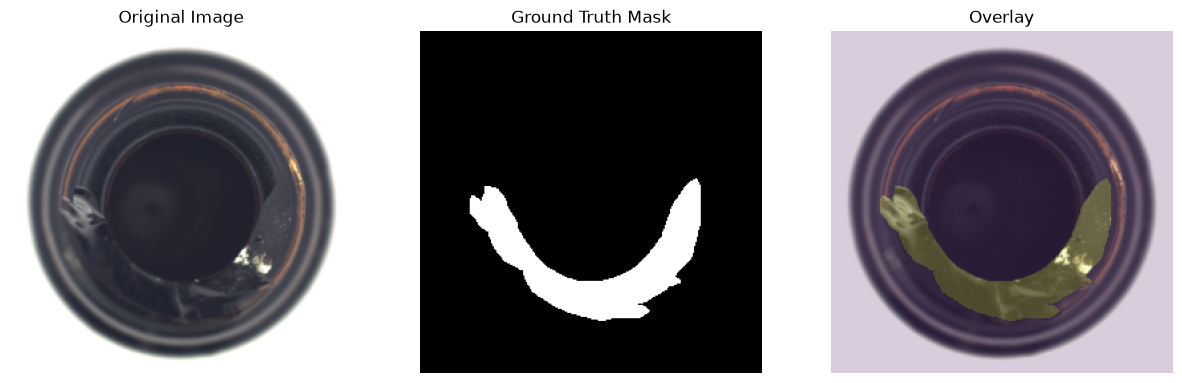

In [11]:
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
image = sample["image"].unsqueeze(0)
mask = sample["mask"].unsqueeze(0)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))


ax[0].imshow((image.squeeze(0) * std + mean).permute(1, 2, 0).cpu())
ax[0].set_title("Original Image")
ax[0].axis("off")

ax[1].imshow(mask.squeeze(0).permute(1, 2, 0).cpu(), cmap="gray")
ax[1].set_title("Ground Truth Mask")
ax[1].axis("off")

ax[2].imshow((image.squeeze(0) * std + mean).permute(1, 2, 0).cpu())
ax[2].imshow(mask.squeeze(0).permute(1, 2, 0).cpu(), cmap="viridis", alpha=0.2)
ax[2].set_title("Overlay")
ax[2].axis("off")

plt.show()

In [13]:
extractor.eval()
with torch.no_grad():
    embeddings = extractor(torch.tensor(image).to(device))
embeddings.shape

C:\Users\Kartik Wadhwa\AppData\Local\Temp\ipykernel_15716\1475737023.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  embeddings = extractor(torch.tensor(image).to(device))


torch.Size([1, 1024, 1536])

In [14]:
patches = embeddings.squeeze(0)
patches.shape

torch.Size([1024, 1536])

In [15]:
distances, indices = nn_model.kneighbors(patches.cpu().numpy())
distances.shape, indices.shape

((1024, 1), (1024, 1))

In [18]:
scores = distances.squeeze()
anomaly_map = scores.reshape(32, 32)
anomaly_map.shape


(32, 32)

In [23]:
image_score = np.mean(np.partition(scores, -50)[-50:])
image_score
max(scores)

np.float64(42.634647369384766)

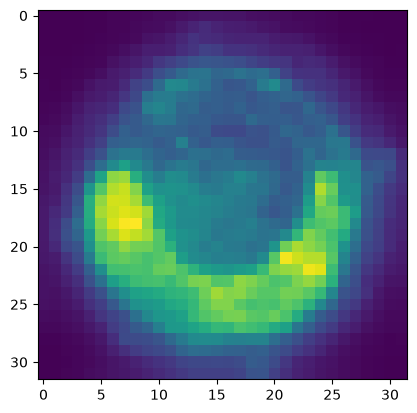

In [24]:
plt.imshow(anomaly_map, cmap="viridis")

In [61]:
heatmap = cv2.resize(anomaly_map,(256, 256))
heatmap.shape

(256, 256)

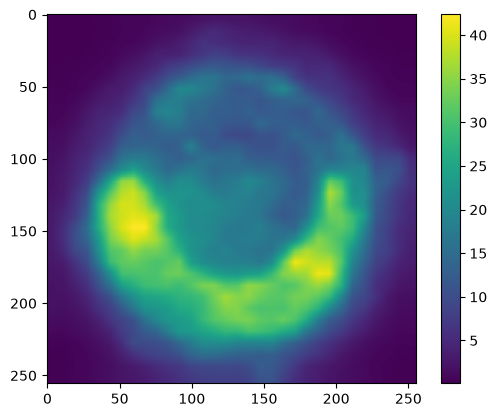

In [62]:
plt.imshow(heatmap, cmap="viridis")
plt.colorbar()
plt.show()

In [63]:
image_score = scores.max()
image_score

np.float64(42.6346435546875)

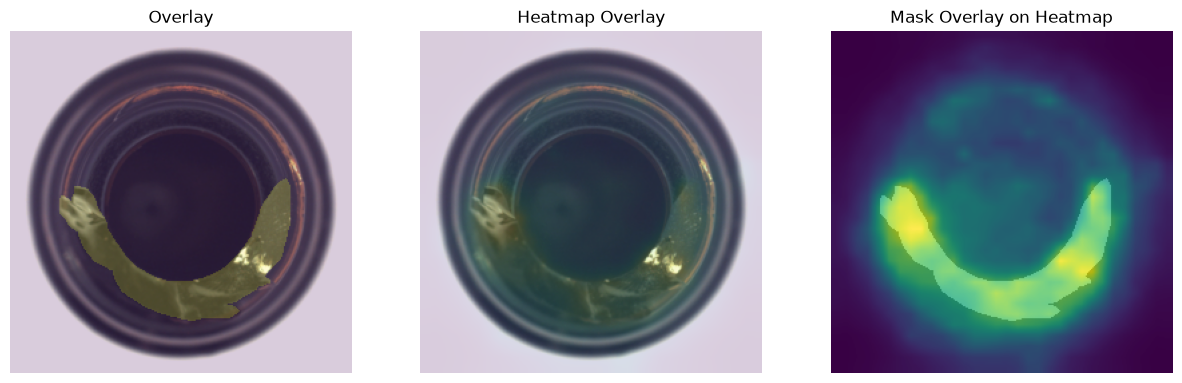

In [71]:
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
image = sample["image"].unsqueeze(0)
mask = sample["mask"].unsqueeze(0)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))


ax[0].imshow((image.squeeze(0) * std + mean).permute(1, 2, 0).cpu())
ax[0].imshow(mask.squeeze(0).permute(1, 2, 0).cpu(), cmap="viridis", alpha=0.2)
ax[0].set_title("Overlay")
ax[0].axis("off")

ax[1].imshow((image.squeeze(0) * std + mean).permute(1, 2, 0).cpu())
ax[1].imshow(heatmap, cmap="viridis", alpha=0.2)
ax[1].set_title("Heatmap Overlay")
ax[1].axis("off")

ax[2].imshow(heatmap, cmap="viridis")
ax[2].imshow(mask.squeeze(0).permute(1, 2, 0).cpu(), cmap="hot", alpha=0.2)
ax[2].set_title("Mask Overlay on Heatmap")
ax[2].axis("off")

plt.show()

In [86]:
def mask_from_heatmap(heatmap, threshold):
    mask = np.zeros_like(heatmap)
    for i in range(heatmap.shape[0]):
        for j in range(heatmap.shape[1]):
            if heatmap[i][j] > threshold:
                mask[i][j] = heatmap[i][j]
    return mask

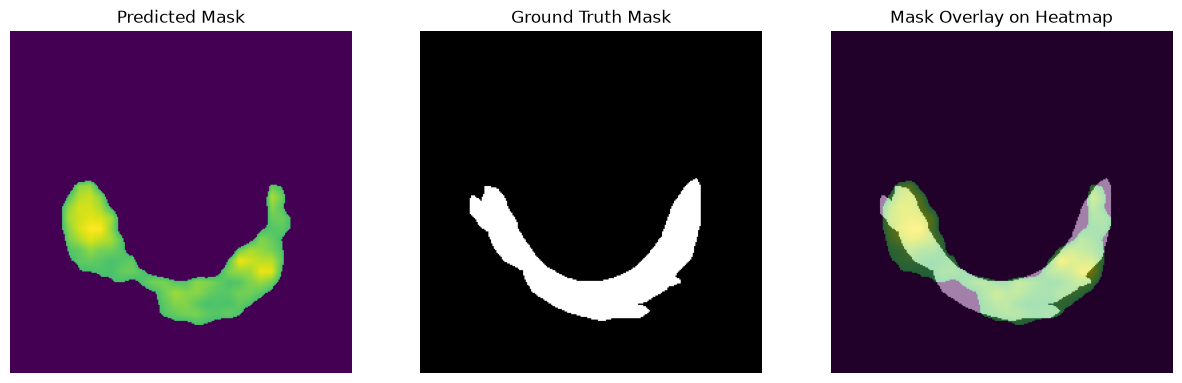

In [108]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
pred_mask = mask_from_heatmap(heatmap, threshold=30)

ax[0].imshow(pred_mask, cmap="viridis")
ax[0].set_title("Predicted Mask")
ax[0].axis("off")

ax[1].imshow(mask.squeeze(0).permute(1, 2, 0), cmap="gray")
ax[1].set_title("Ground Truth Mask")
ax[1].axis("off")

ax[2].imshow(mask.squeeze(0).permute(1, 2, 0), cmap="gray")
ax[2].imshow(pred_mask, cmap="viridis", alpha=0.5)
ax[2].set_title("Mask Overlay on Heatmap")
ax[2].axis("off")

plt.show()

In [117]:
heatmap.flatten().shape

(65536,)

In [114]:
mask.numpy().flatten().shape

(65536,)

In [118]:
pixel_auc = roc_auc_score(mask.numpy().flatten(), heatmap.flatten())

print("Pixel AUROC:", pixel_auc)

Pixel AUROC: 0.9861861047060262


In [ ]:
def test_one_image(memory_bank, dataset, idx=0):
    extractor.to(device)
    extractor.eval()
    nn_model = NearestNeighbors(n_neighbors=1, metric="euclidean").fit(memory_bank.numpy())

    sample = dataset[idx]["image"].unsqueeze(0).to(device)
    mask = dataset[idx]["mask"].unsqueeze(0)
    label = dataset[idx]["label"]

    start = time.time()
    with torch.no_grad():
        embeddings = extractor(sample)
    end = time.time()
    print(f"Feature extraction time: {end - start:.4f} seconds")

    patches = embeddings.squeeze(0)    

    start = time.time()
    distances, indices = nn_model.kneighbors(patches.cpu())
    end = time.time()
    print(f"KNN search time: {end - start:.4f} seconds")

    scores = distances.squeeze()
    anomaly_map = scores.reshape(32, 32)
    heatmap = cv2.resize(anomaly_map, (256, 256))

    image_score = scores.max()
    print(f"Image score: {image_score:.4f}")
    pixel_auc = roc_auc_score(mask.numpy().flatten(), heatmap.flatten())
    print("Pixel AUROC:", pixel_auc)

In [42]:
pixel_gt = []
pixel_pred = []

image_gt = []
image_pred = []

extractor_time = []
knn_time = []

dataset = MVTecDataset(data_path / "bottle", split="test", return_mask=True)

pca = PCA(n_components=128, svd_solver="randomized", random_state=42)
memory_bank_pca = pca.fit_transform(memory_bank_small.numpy())

nn_model = NearestNeighbors(n_neighbors=1, metric="euclidean").fit(memory_bank_pca)

extractor.to(device)
test_loader = DataLoader(dataset, batch_size=8, shuffle=False, pin_memory=True)
extractor.eval()
with torch.no_grad():
    for sample in tqdm.tqdm(test_loader):
        images = sample["image"].to(device, non_blocking=True)
        masks = sample["mask"].cpu()
        labels = sample["label"].cpu()
        start = time.time()
        embeddings = extractor(images)
        end = time.time()
        extractor_time.append(end - start)

        B, P, D = embeddings.shape
        all_patches = embeddings.cpu().numpy().reshape(-1, D)
        all_patches_pca = pca.transform(all_patches)

        start = time.time()
        distances, _ = nn_model.kneighbors(all_patches_pca)
        end = time.time()
        knn_time.append(end - start)
        distances = distances.reshape(B, P)

        for i in range(B):
            scores = distances[i]

            image_score = np.partition(scores, -50)[-50:].mean()
            anomaly_map = scores.reshape(32, 32)
            heatmap = cv2.resize(anomaly_map, (256, 256))

            pixel_gt.extend(masks[i].squeeze().numpy().flatten())
            pixel_pred.extend(heatmap.flatten())

            image_gt.append(labels[i].item())
            image_pred.append(image_score)

print(f"Average feature extraction time per batch: {np.mean(extractor_time):.4f} seconds")
print(f"Average KNN search time per batch: {np.mean(knn_time):.4f} seconds")   

image_auc = roc_auc_score(image_gt, image_pred)
pixel_auc = roc_auc_score(pixel_gt, pixel_pred)

print("Image AUROC:", image_auc)
print("Pixel AUROC:", pixel_auc)

100%|██████████| 11/11 [00:18<00:00,  1.64s/it]


Average feature extraction time per batch: 0.0263 seconds
Average KNN search time per batch: 0.8967 seconds
Image AUROC: 1.0
Pixel AUROC: 0.980366224291917


In [45]:
# np.array(image_gt)
# np.array(image_pred)
print(np.array(image_pred)[np.array(image_gt) == 0].max())
print(np.array(image_pred)[np.array(image_gt) == 1].min())

15.937365550994873
16.345115623474122


In [48]:
results = []
for item in os.listdir(data_path):
    pixel_gt = []
    pixel_pred = []

    image_gt = []
    image_pred = []

    extractor_time = []
    knn_time = []
    
    dataset = MVTecDataset(data_path / item, split="test", return_mask=True)

    n_split = 0.075
    memory_bank = torch.load(embeddings_path / f"memory_bank_{item}.pt", map_location="cpu", weights_only=True)
    num_samples = int(n_split * len(memory_bank))
    indices = torch.randperm(len(memory_bank))[:num_samples]
    memory_bank_small = memory_bank[indices]

    pca_dim = 128
    pca = PCA(n_components=pca_dim, svd_solver="randomized", random_state=42)
    memory_bank_pca = pca.fit_transform(memory_bank_small.numpy())

    nn_model = NearestNeighbors(n_neighbors=1, metric="euclidean").fit(memory_bank_pca)

    extractor.to(device)
    test_loader = DataLoader(dataset, batch_size=8, shuffle=False, num_workers=0, pin_memory=True)
    extractor.eval()
    with torch.no_grad():
        for sample in tqdm.tqdm(test_loader):
            images = sample["image"].to(device, non_blocking=True)
            masks = sample["mask"].cpu()
            labels = sample["label"].cpu()

            start = time.time()
            embeddings = extractor(images)
            end = time.time()
            extractor_time.append(end - start)

            B, P, D = embeddings.shape
            all_patches = embeddings.cpu().numpy().reshape(-1, D)
            all_patches_pca = pca.transform(all_patches)

            start = time.time()
            distances, _ = nn_model.kneighbors(all_patches_pca)
            end = time.time()
            knn_time.append(end - start)
            distances = distances.reshape(B, P)

            for i in range(B):
                scores = distances[i]

                image_score = np.partition(scores, -50)[-50:].mean()
                anomaly_map = scores.reshape(32, 32)
                heatmap = cv2.resize(anomaly_map, (256, 256))

                pixel_gt.extend(masks[i].squeeze().numpy().flatten())
                pixel_pred.extend(heatmap.flatten())

                image_gt.append(labels[i].item())
                image_pred.append(image_score)
    print(f"Results for {item}:")
    print(f"Average feature extraction time per batch: {np.mean(extractor_time):.4f} seconds")
    print(f"Average KNN search time per batch: {np.mean(knn_time):.4f} seconds")   

    image_auc = roc_auc_score(image_gt, image_pred)
    pixel_auc = roc_auc_score(pixel_gt, pixel_pred)

    print("Maximum score for normal images:", np.array(image_pred)[np.array(image_gt) == 0].max())
    print("Average score for normal images:", np.array(image_pred)[np.array(image_gt) == 0].mean())
    print("Minimum score for normal images:", np.array(image_pred)[np.array(image_gt) == 0].min())
    print("Maximum score for defective images:", np.array(image_pred)[np.array(image_gt) == 1].max())
    print("Average score for defective images:", np.array(image_pred)[np.array(image_gt) == 1].mean())
    print("Minimum score for defective images:", np.array(image_pred)[np.array(image_gt) == 1].min())
    print("-" * 50)
    threshold = np.percentile(np.array(image_pred)[np.array(image_gt) == 0], 95)
    print("Threshold:", threshold)
    print("Image AUROC:", image_auc)
    print("Pixel AUROC:", pixel_auc)
    print("-" * 50)
    print("-" * 50)

    # results.append({
    #     "sample": item,
    #     "feature_extraction_time": np.mean(extractor_time),
    #     "knn_search_time": np.mean(knn_time),
    #     "image_auroc": image_auc,
    #     "pixel_auroc": pixel_auc,
    #     "pca_dim": pca_dim,
    #     "n_split": n_split
    # })

# df = pd.DataFrame(results)
# df.to_csv(project_root / "results" / f"knn_results_summary_5.csv", index=False)
    

100%|██████████| 11/11 [00:18<00:00,  1.67s/it]


Results for bottle:
Average feature extraction time per batch: 0.0308 seconds
Average KNN search time per batch: 0.7542 seconds
Maximum score for normal images: 16.32909746170044
Average score for normal images: 14.780861673355101
Minimum score for normal images: 13.201044788360596
Maximum score for defective images: 26.81866321563721
Average score for defective images: 22.29182899717301
Minimum score for defective images: 16.319913692474366
--------------------------------------------------
Threshold: 15.960073048591614
Image AUROC: 0.9992063492063492
Pixel AUROC: 0.9802687746762886
--------------------------------------------------
--------------------------------------------------


100%|██████████| 19/19 [00:29<00:00,  1.56s/it]


Results for cable:
Average feature extraction time per batch: 0.0132 seconds
Average KNN search time per batch: 0.7800 seconds
Maximum score for normal images: 22.634442443847657
Average score for normal images: 21.40628019661739
Minimum score for normal images: 20.646266899108888
Maximum score for defective images: 29.28377185821533
Average score for defective images: 23.825789599211326
Minimum score for defective images: 21.824595375061037
--------------------------------------------------
Threshold: 22.18853303337097
Image AUROC: 0.9904422788605696
Pixel AUROC: 0.9626275563274053
--------------------------------------------------
--------------------------------------------------


100%|██████████| 17/17 [00:27<00:00,  1.61s/it]


...

Results for hazelnut:
Average feature extraction time per batch: 0.0229 seconds
Average KNN search time per batch: 1.2423 seconds
Maximum score for normal images: 20.56386333465576
Average score for normal images: 19.188892181396486
Minimum score for normal images: 18.232239875793457
Maximum score for defective images: 24.820899620056153
Average score for defective images: 22.601322404044012
Minimum score for defective images: 20.589488067626952
--------------------------------------------------
Threshold: 19.89386159133911
Image AUROC: 1.0
Pixel AUROC: 0.9842368578528823
--------------------------------------------------
--------------------------------------------------


100%|██████████| 16/16 [00:25<00:00,  1.62s/it]


Results for leather:
Average feature extraction time per batch: 0.0413 seconds
Average KNN search time per batch: 0.7973 seconds
Maximum score for normal images: 18.0306205368042
Average score for normal images: 17.337647418975827
Minimum score for normal images: 16.70128330230713
Maximum score for defective images: 23.050759735107423
Average score for defective images: 19.6641714780227
Minimum score for defective images: 17.560990028381347
--------------------------------------------------
Threshold: 17.88387247085571
Image AUROC: 0.9966032608695652
Pixel AUROC: 0.9943329319527028
--------------------------------------------------
--------------------------------------------------


  7%|▋         | 1/15 [00:02<00:28,  2.02s/it]


KeyboardInterrupt: 

In [27]:
df = pd.DataFrame(results)
df.to_csv(project_root / "results" / f"knn_results_summary_1.csv", index=False)

# Optimizations (Random Selection, Coreset Subsampling)

In [21]:
num_samples = int(0.075 * len(memory_bank))

indices = torch.randperm(len(memory_bank))[:num_samples]

memory_bank_small = memory_bank[indices]

In [30]:
df = pd.read_csv(project_root / "results" / f"knn_results_summary_1.csv")
df.head()

,sample,feature_extraction_time,knn_search_time,image_auroc,pixel_auroc,n_split
0,bottle,0.024505,2.046079,1.000000,0.981302,0.1
1,cable,0.020708,2.048997,0.980885,0.957655,0.1
2,capsule,0.017886,2.308620,0.940168,0.973549,0.1
3,carpet,0.019989,2.808934,0.956661,0.982946,0.1
4,grid,0.016238,2.606706,0.870510,0.964219,0.1


In [31]:
df.insert(loc=5, column="pca_dim", value=256)
df.head()

,sample,feature_extraction_time,knn_search_time,image_auroc,pixel_auroc,pca_dim,n_split
0,bottle,0.024505,2.046079,1.000000,0.981302,256,0.1
1,cable,0.020708,2.048997,0.980885,0.957655,256,0.1
2,capsule,0.017886,2.308620,0.940168,0.973549,256,0.1
3,carpet,0.019989,2.808934,0.956661,0.982946,256,0.1
4,grid,0.016238,2.606706,0.870510,0.964219,256,0.1


In [32]:
df.to_csv(project_root / "results" / f"knn_results_summary_1.csv", index=False)

In [34]:
for csv in os.listdir(project_root / "results"):
    df = pd.read_csv(project_root / "results" / csv)
    print(f"Results from {csv}: {df['pca_dim'].unique()[0]}, n_split: {df['n_split'].unique()[0]}")
    print("Average feature extraction time:", df["feature_extraction_time"].mean())
    print("Average KNN search time:", df["knn_search_time"].mean())
    print("Average Image AUROC:", df["image_auroc"].mean())
    print("Average Pixel AUROC:", df["pixel_auroc"].mean())
    print("-" * 50)

Results from knn_results_summary_1.csv: 256, n_split: 0.1
Average feature extraction time: 0.018729271136731507
Average KNN search time: 2.080815093030981
Average Image AUROC: 0.9564954795145706
Average Pixel AUROC: 0.955764324879236
--------------------------------------------------
Results from knn_results_summary_2.csv: 64, n_split: 0.075
Average feature extraction time: 0.025578429264306608
Average KNN search time: 0.5881049916712158
Average Image AUROC: 0.9344003228683698
Average Pixel AUROC: 0.9406511930125031
--------------------------------------------------
Results from knn_results_summary_3.csv: 128, n_split: 0.075
Average feature extraction time: 0.016762426146916164
Average KNN search time: 0.8217201909870642
Average Image AUROC: 0.947797169242876
Average Pixel AUROC: 0.9500898879314875
--------------------------------------------------
Results from knn_results_summary_4.csv: 64, n_split: 0.1
Average feature extraction time: 0.017530285000651794
Average KNN search time: 0.7

# Testing knn.py

In [9]:
from knn import knn_scoring, evaluate_category, evaluate_dataset

In [4]:
n_split = 0.075
memory_bank = torch.load(embeddings_path / f"memory_bank_bottle.pt", map_location="cpu")
num_samples = int(n_split * len(memory_bank))
indices = torch.randperm(len(memory_bank))[:num_samples]
memory_bank_small = memory_bank[indices]

C:\Users\Kartik Wadhwa\AppData\Local\Temp\ipykernel_15716\3122834195.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  memory_bank = torch.load(embeddings_path / f"memory_

In [4]:
n_split = 0.1
memory_bank = torch.load(embeddings_path / f"memory_bank_bottle.pt", map_location="cpu")
num_samples = int(n_split * len(memory_bank))
indices = torch.randperm(len(memory_bank))[:num_samples]
memory_bank_small = memory_bank[indices]

pca_dim = 128
pca = PCA(n_components=pca_dim, svd_solver="randomized", random_state=42)
memory_bank_pca = pca.fit_transform(memory_bank_small.numpy())

nn_model = NearestNeighbors(n_neighbors=1, metric="euclidean").fit(memory_bank_pca)

C:\Users\Kartik Wadhwa\AppData\Local\Temp\ipykernel_26540\362520526.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  memory_bank = torch.load(embeddings_path / f"memory_b

In [11]:
extractor.eval()
extractor.to(device)
scores, heatmap = knn_scoring(sample["image"],memory_bank_pca, nn_model, extractor, pca)

ValueError: expected 4D input (got 3D input)

In [49]:
for item in os.listdir(data_path):
    pixel_gt = []
    pixel_pred = []

    image_gt = []
    image_pred = []

    extractor_time = []
    knn_time = []
    
    dataset = MVTecDataset(data_path / item, split="train", return_mask=False)

    n_split = 0.075
    memory_bank = torch.load(embeddings_path / f"memory_bank_{item}.pt", map_location="cpu", weights_only=True)
    num_samples = int(n_split * len(memory_bank))
    indices = torch.randperm(len(memory_bank))[:num_samples]
    memory_bank_small = memory_bank[indices]

    pca_dim = 128
    pca = PCA(n_components=pca_dim, svd_solver="randomized", random_state=42)
    memory_bank_pca = pca.fit_transform(memory_bank_small.numpy())

    nn_model = NearestNeighbors(n_neighbors=1, metric="euclidean").fit(memory_bank_pca)

    extractor.to(device)
    test_loader = DataLoader(dataset, batch_size=8, shuffle=False, num_workers=0, pin_memory=True)
    extractor.eval()
    with torch.no_grad():
        for sample in tqdm.tqdm(test_loader):
            images = sample["image"].to(device, non_blocking=True)
        
            start = time.time()
            embeddings = extractor(images)
            end = time.time()
            extractor_time.append(end - start)

            B, P, D = embeddings.shape
            all_patches = embeddings.cpu().numpy().reshape(-1, D)
            all_patches_pca = pca.transform(all_patches)

            start = time.time()
            distances, _ = nn_model.kneighbors(all_patches_pca)
            end = time.time()
            knn_time.append(end - start)
            distances = distances.reshape(B, P)

            for i in range(B):
                scores = distances[i]
                image_score = np.partition(scores, -50)[-50:].mean()
                image_pred.append(image_score)
    print(f"Results for {item}:")
    print(f"Average feature extraction time per batch: {np.mean(extractor_time):.4f} seconds")
    print(f"Average KNN search time per batch: {np.mean(knn_time):.4f} seconds")   

    threshold = np.percentile(np.array(image_pred), 95)
    print("Threshold:", threshold)
    print("-" * 50)
    print("-" * 50)


100%|██████████| 27/27 [00:32<00:00,  1.22s/it]


Results for bottle:
Average feature extraction time per batch: 0.0200 seconds
Average KNN search time per batch: 0.6827 seconds
Threshold: 15.371407432556152
--------------------------------------------------
--------------------------------------------------


100%|██████████| 28/28 [00:38<00:00,  1.38s/it]


Results for cable:
Average feature extraction time per batch: 0.0122 seconds
Average KNN search time per batch: 0.7152 seconds
Threshold: 21.915404193878175
--------------------------------------------------
--------------------------------------------------


 25%|██▌       | 7/28 [00:11<00:34,  1.62s/it]


KeyboardInterrupt: 